### Sjukdomar jämfört mot Blodtryckskategori, BMI, Rökare

Text(0.5, 1.0, 'Cardio sick and Smokers')

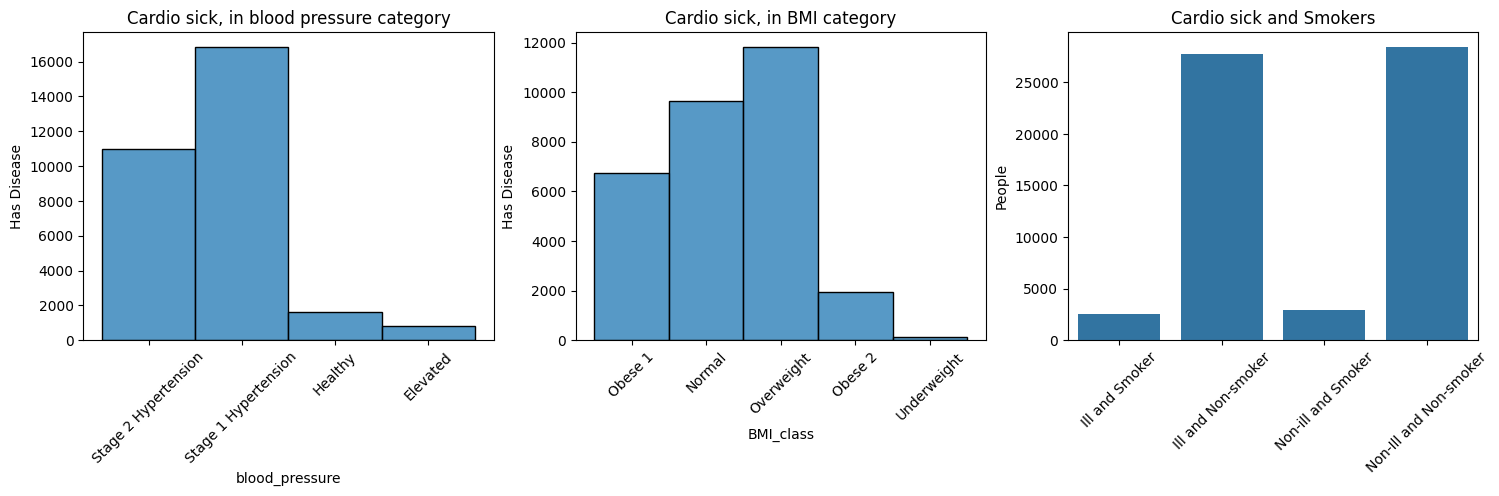

In [34]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv('revised_data.csv', index_col=0)
ill_true = df[df['cardio'] == 1]
fig, axes = plt.subplots(1,3)
fig.set_size_inches(18,4)
#rotate labels
axes[0].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='x', rotation=45)
axes[2].tick_params(axis='x', rotation=45)


sns.histplot(ill_true['blood_pressure'], ax=axes[0])
axes[0].set(ylabel = 'Has Disease')
axes[0].set_title('Cardio sick, in blood pressure category')

sns.histplot(ill_true['BMI_class'], ax=axes[1])
axes[1].set(ylabel = 'Has Disease')
axes[1].set_title('Cardio sick, in BMI category')

#Jämför Rökare om de har hjärtsjukdomar eller inte
sns.barplot([len(df[(df['cardio'] == 1) & (df['smoke'] == 1)]), 
            len(df[(df['cardio'] == 1) & (df['smoke'] == 0)]), 
            len(df[(df['cardio'] == 0) & (df['smoke'] == 1)]),
            len(df[(df['cardio'] == 0) & (df['smoke'] == 0)])],
            ax=axes[2])

axes[2].set(ylabel = 'People')
axes[2].set_xticks(ticks= [0,1,2,3], labels=['Ill and Smoker', 'Ill and Non-smoker', 'Non-ill and Smoker', 'Non-Ill and Non-smoker'])
axes[2].set_title('Cardio sick and Smokers')


### Korrelation

<Axes: >

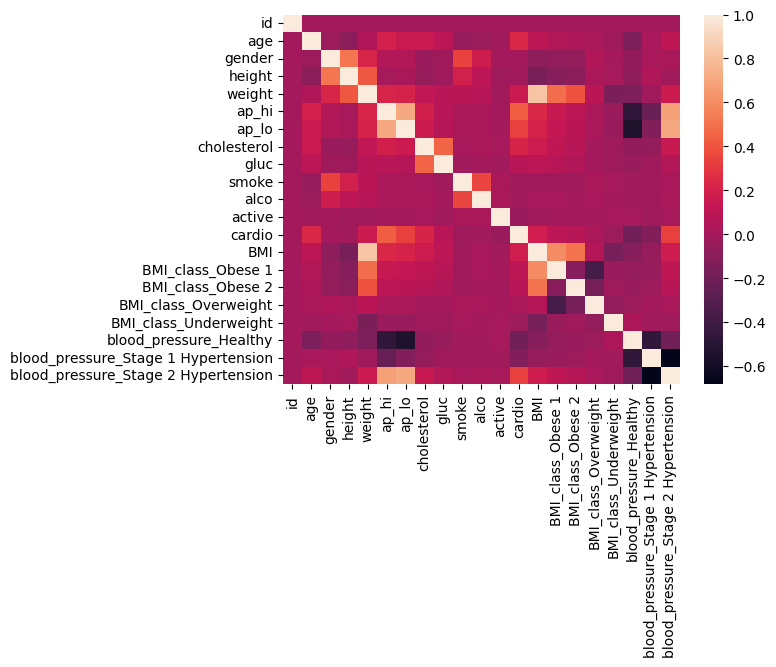

In [38]:
dummies = pd.get_dummies(df, drop_first=True)
sns.heatmap(dummies.corr())

### Slutsats
- De största korrelationerna finns mellan skapade Features som är skapade av originaldatan vilket är rimligt
- BMI har stark korrelation med weight, inte så konstigt eftersom weight är en beroende variabel till att räkna ut BMI
- ap_hi och ap_lo (systoliskt och diastoliskt blodtryck) har stark korrelation med blood_pressure kategorierna. Även kategorierna är skapade av ap_hi och ap_lo.